In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, FalseNegatives, FalsePositives, TrueNegatives, TruePositives, AUC
from tensorflow.math import confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.python.keras.utils import layer_utils

In [4]:
TRAINING_DIR = r"D:\cap stone project\Data set\Train"
TEST_DIR = r"D:\cap stone project\Data set\Test"
VALIDATION_DIR = r"D:\cap stone project\Data set\Validation"

print(f'Total training images REAL: {len(os.listdir(os.path.join(TRAINING_DIR, "real")))}')
print(f'Total training images FAKE: {len(os.listdir(os.path.join(TRAINING_DIR, "fake")))}\n')

print(f'Total test images REAL: {len(os.listdir(os.path.join(TEST_DIR, "real")))}')
print(f'Total test images FAKE: {len(os.listdir(os.path.join(TEST_DIR, "fake")))}\n')

print(f'Total test images REAL: {len(os.listdir(os.path.join(VALIDATION_DIR, "real")))}')
print(f'Total test images FAKE: {len(os.listdir(os.path.join(VALIDATION_DIR, "fake")))}')


Total training images REAL: 70001
Total training images FAKE: 70001

Total test images REAL: 5413
Total test images FAKE: 5492

Total test images REAL: 19787
Total test images FAKE: 19641


In [5]:
training_datagen = ImageDataGenerator(
    rescale=1./255,
    #validation_split=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

img_size = 224
img_batch = 32

train_generator = training_datagen.flow_from_directory(
    TRAINING_DIR,
    subset='training',
    target_size=(img_size, img_size),
    shuffle=True,
    class_mode='binary',
    batch_size=img_batch
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    #subset='validation',
    target_size=(img_size, img_size),
    shuffle=True,
    class_mode='binary',
    batch_size=img_batch
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(img_size, img_size),
    class_mode='binary',
    batch_size=img_batch,
    shuffle=False
)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


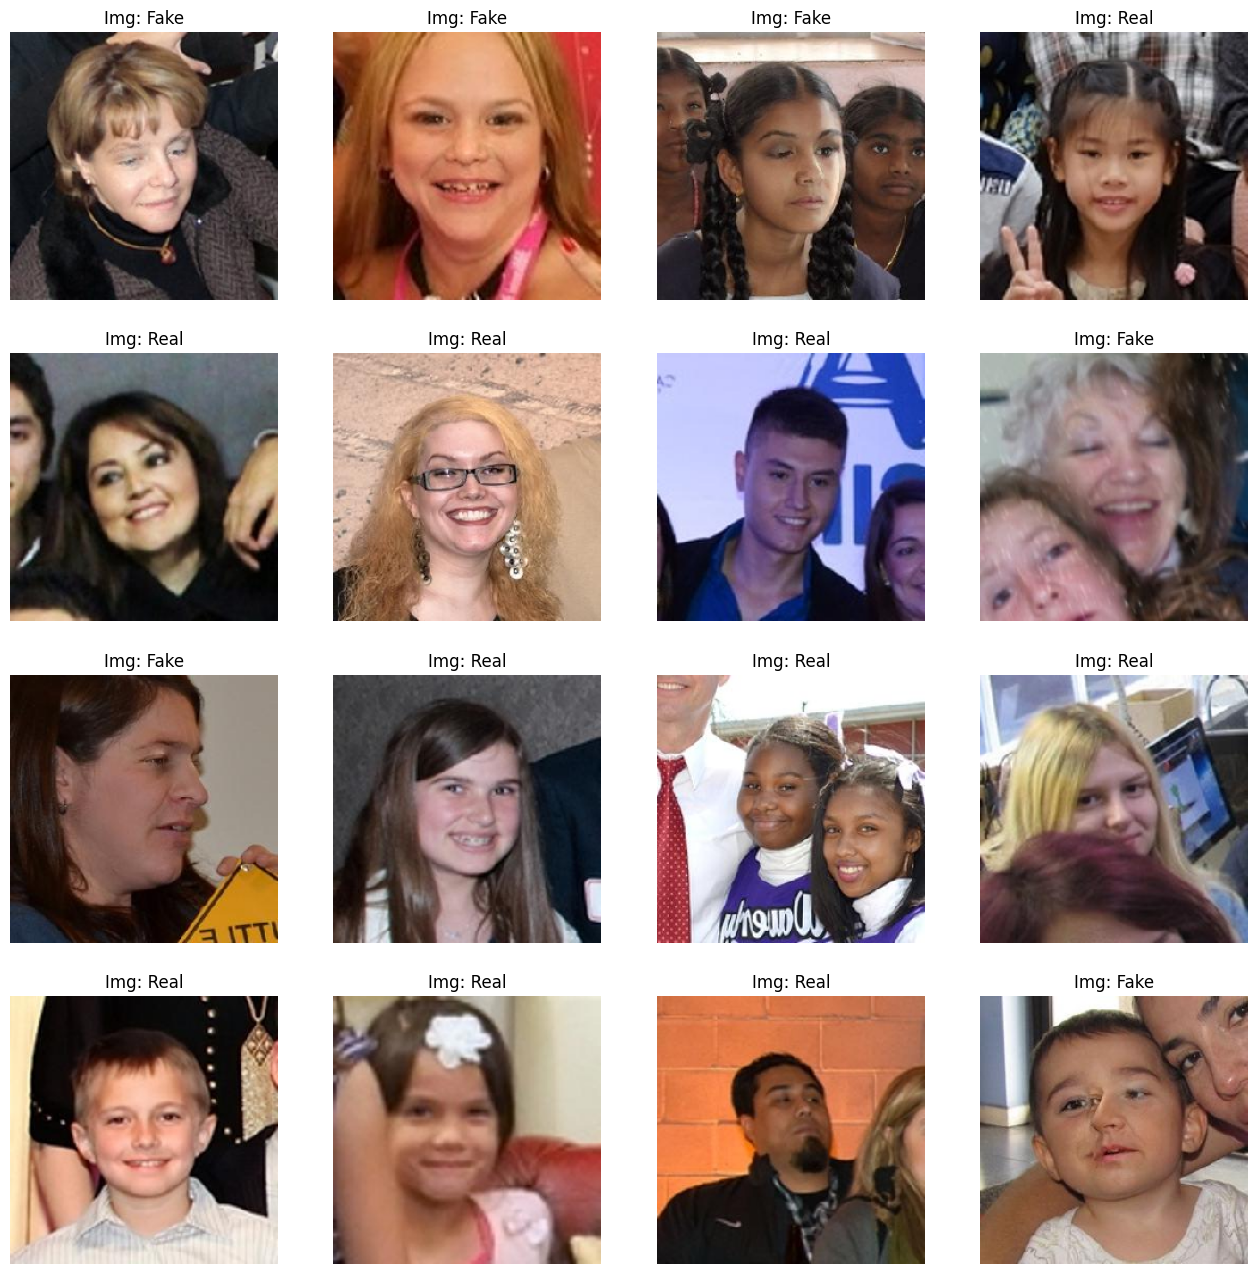

In [6]:
labels = {1.0: 'Real', 0.0: 'Fake'}

for images, images_labels in train_generator:
    plt.figure(figsize=(16, 16))
    
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.title(f'Img: {labels[images_labels[i]]}')
        plt.imshow(np.uint8(255 * images[i]))
        plt.axis('off')
    break

In [14]:
# Load pre-trained InceptionV3 with frozen layers
pre_trained_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in pre_trained_model.layers:
    layer.trainable = False  # Freeze pre-trained layers

# Add custom layers for classification
last_layer = pre_trained_model.output
x = Flatten(name='flatten')(last_layer)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid', name='output')(x)  
# Create the final model
model = Model(pre_trained_model.input, out)
# Compile the model
model.compile(
    loss=binary_crossentropy,
    optimizer=Adam(learning_rate=0.001),  
    metrics=['accuracy']
)

callback = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='model_inceptionv3.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    verbose=1,
    callbacks=callback
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6831 - loss: 3.7643
Epoch 1: val_loss improved from inf to 0.39346, saving model to model_inceptionv3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 820s 3s/step - accuracy: 0.6833 - loss: 3.7567 - val_accuracy: 0.8235 - val_loss: 0.3935
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7750 - loss: 0.4622
Epoch 2: val_loss improved from 0.39346 to 0.38596, saving model to model_inceptionv3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 781s 2s/step - accuracy: 0.7750 - loss: 0.4622 - val_accuracy: 0.8285 - val_loss: 0.3860
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7952 - loss: 0.4253
Epoch 3: val_loss did not improve from 0.38596
313/313 ━━━━━━━━━━━━━━━━━━━━ 776s 2s/step - accuracy: 0.7952 - loss: 0.4253 - val_accuracy: 0.8135 - val_loss: 0.4036
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8135 - loss: 0.4054
Epoch 4: val_loss improved from 0.38596 to 0.35012, saving model to model_incep

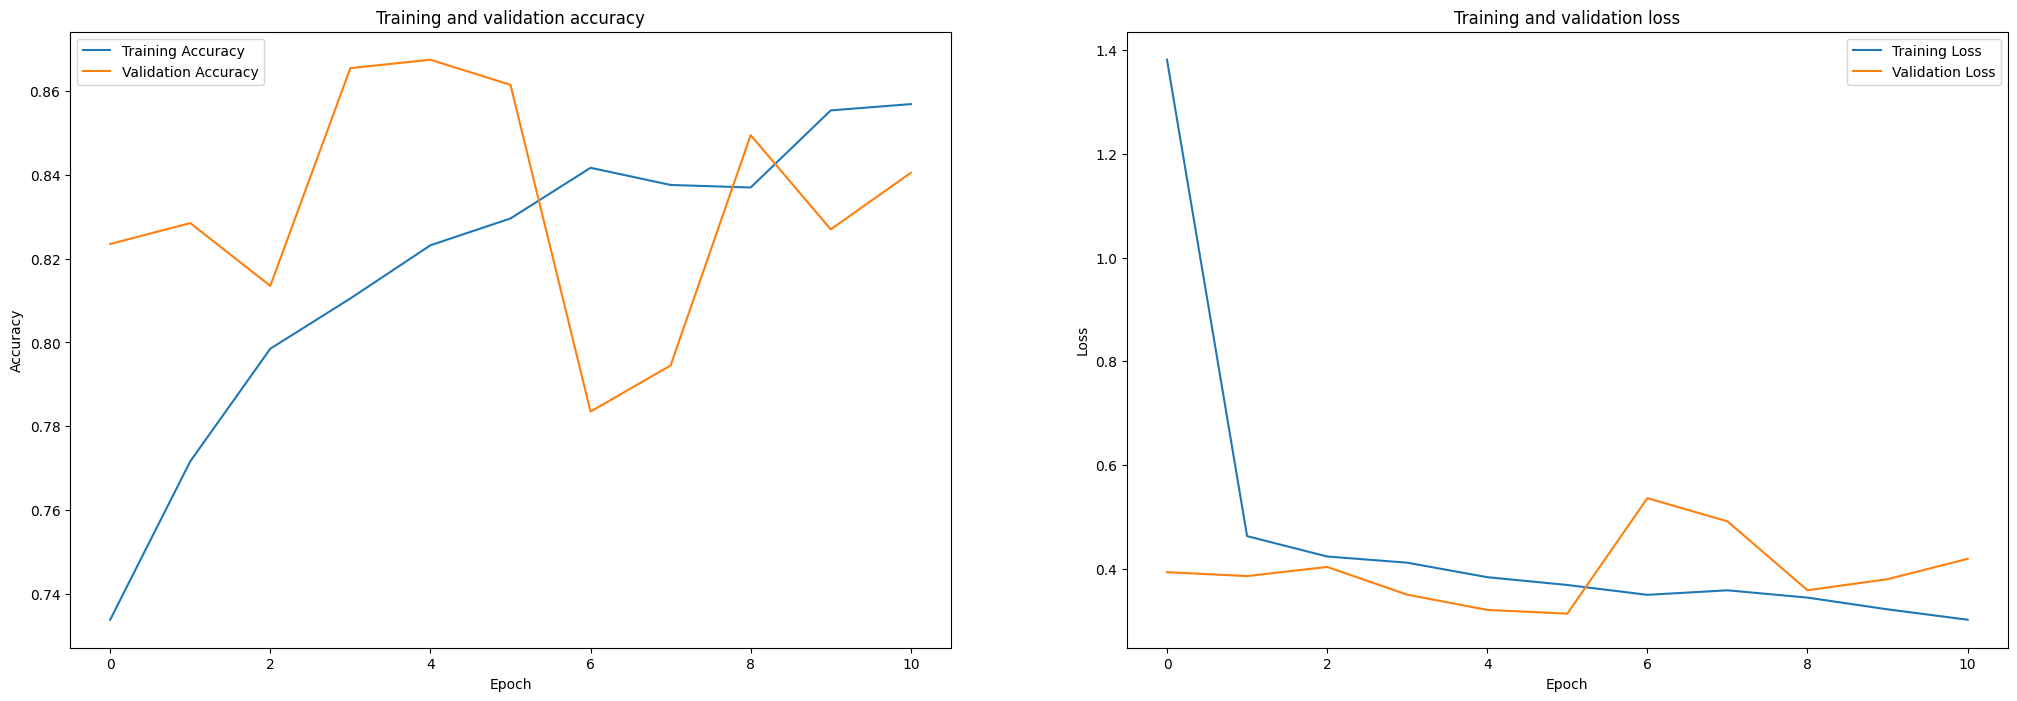

In [15]:
plt.figure(figsize=(25, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [16]:
metrics = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
index_model_checkpoint = np.argmin(history.history['val_loss'])
[f'Best {metric}: {history.history[metric][index_model_checkpoint]:.2f}' for metric in metrics]

['Best accuracy: 0.83',
 'Best val_accuracy: 0.86',
 'Best loss: 0.37',
 'Best val_loss: 0.31']

In [7]:
def load_and_test_model(model_name, test_set, display_model_summary=False):
    try:
        loaded_model = tf.keras.models.load_model(f'model_inceptionv3.keras')
    except OSError:
        print('The model called does not exist. Testing for the last saved model.')
        loaded_model = tf.keras.models.load_model('model_inceptionv3.keras') # This is the name used in the ModelCheckpoint
    if display_model_summary:
        loaded_model.summary()
    test_loss, test_acc = loaded_model.evaluate(test_set)
    print(f'Test loss: {round(test_loss, 2)}, Test accuracy: {round(test_acc * 100, 2)}')

In [9]:
load_and_test_model('model_inceptionv3.keras', test_generator)

341/341 ━━━━━━━━━━━━━━━━━━━━ 746s 2s/step - accuracy: 0.5918 - loss: 0.8878
Test loss: 0.6, Test accuracy: 73.86


In [10]:
def calculate_model_performance_metrics(model_name, test_dataset, transfer_ml=False, model_version=0,
                                        show_plots=False):
    
    try:
        loaded_model = tf.keras.models.load_model(f'model_inceptionv3.keras')
        print(f'Calculating performance metrics for model_inceptionv3')
    except OSError:
        print('The model called does not exist. Testing for the last saved model.')
        loaded_model = tf.keras.models.load_model('model_inceptionv3.keras')

    if transfer_ml and model_version != 0:
        test_images, true_labels = test_dataset.as_numpy_iterator().next()
        test_images = layer_utils.preprocess_input(test_images, version=model_version)
        predictions_sigmoid = loaded_model.predict(test_images, verbose=1)
    else:
        true_labels = test_dataset.labels
        predictions_sigmoid = loaded_model.predict(test_dataset, verbose=1)
    
    false_positives_negatives = []
    lower_bound_threshold = 0.2
    upper_bound_threshold = 0.7
    step = 0.001

    sigmoid_threshold = np.arange(lower_bound_threshold, upper_bound_threshold, step)

    for threshold in sigmoid_threshold:
        predictions_binary = tf.where(predictions_sigmoid > threshold, 1, 0)
        conf_matrix = confusion_matrix(true_labels, predictions_binary)
        false_positives_negatives.append(conf_matrix[0][1] + conf_matrix[1][0])

    min_threshold = sigmoid_threshold[np.argmin(false_positives_negatives)]
    print(f'Minimizer of false positives and false negatives: {min_threshold:.3f}')

    metrics_options = {
        'Precision': Precision,
        'Recall': Recall,
        'True Positives': TruePositives,
        'True Negatives': TrueNegatives,
        'False Positives': FalsePositives,
        'False Negatives': FalseNegatives
    }

    def disp_metrics(metric, threshold_value=min_threshold, verbose=False):
        metrics = metrics_options[metric](thresholds=threshold_value)
        metrics.update_state(true_labels, predictions_sigmoid)
        result = metrics.result().numpy()
        if verbose:
            print(f'{metric}: {result:.3f}')
        return result

    bin_acc = BinaryAccuracy(threshold=min_threshold)
    bin_acc.update_state(true_labels, predictions_sigmoid)
    print(f'Binary Accuracy: {bin_acc.result().numpy():.3f}')

    for metric in metrics_options.keys():
        disp_metrics(metric, verbose=True)

    rights = disp_metrics('True Positives') + disp_metrics('True Negatives')
    wrongs = disp_metrics('False Positives') + disp_metrics('False Negatives')
    print(f'Number of right guesses: {rights:.3f}')
    print(f'Number of wrong guesses: {wrongs:.3f}')

    auc = AUC()
    auc.update_state(true_labels, predictions_sigmoid)
    auc = auc.result().numpy()
    print(f'Area under curve ROC: {auc:.3f}')

    precision = disp_metrics('Precision')
    recall = disp_metrics('Recall')

    f1_score = 2 * (precision * recall) / (precision + recall)
    print(f'F1-Score: {f1_score:.3f}')


    if show_plots:
        
        plt.figure(figsize=(18, 14))
    
        plt.subplot(2, 2, 1)
        plt.plot(sigmoid_threshold, false_positives_negatives, linewidth=3)
        plt.title('Sum of false positives and false negatives as a function of sigmoid threshold')
        plt.xlabel('Sigmoid threshold')
        plt.ylabel('False positives + False negatives')

        plt.subplot(2, 2, 2)
        cm = confusion_matrix(true_labels, tf.where(predictions_sigmoid > min_threshold, 1, 0))
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title(f'Confusion matrix @{min_threshold:.3f}')
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')

        plt.subplot(2, 2, 3)
        false_positive_rate, true_positive_rate, _ = roc_curve(true_labels, predictions_sigmoid)
        plt.plot(false_positive_rate, true_positive_rate, linewidth=4)
        plt.title(f'Receiver Operating Characteristic curve for AUC: {auc:.3f}')
        plt.xlabel('False positive rate')
        plt.ylabel('True positives rate')
        plt.grid(True)

        plt.subplot(2, 2, 4)
        prec, rec, _ = precision_recall_curve(true_labels, predictions_sigmoid)
        plt.plot(rec, prec, linewidth=4)
        avg_precision_score = average_precision_score(true_labels, predictions_sigmoid)
        plt.title(f'Precision-Recall curve | Average precision score: {avg_precision_score:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid(True)
    
    return min_threshold

Calculating performance metrics for model_inceptionv3
341/341 ━━━━━━━━━━━━━━━━━━━━ 757s 2s/step
Minimizer of false positives and false negatives: 0.696
Binary Accuracy: 0.761
Precision: 0.727
Recall: 0.830
True Positives: 4494.000
True Negatives: 3802.000
False Positives: 1690.000
False Negatives: 919.000
Number of right guesses: 8296.000
Number of wrong guesses: 2609.000
Area under curve ROC: 0.847
F1-Score: 0.775


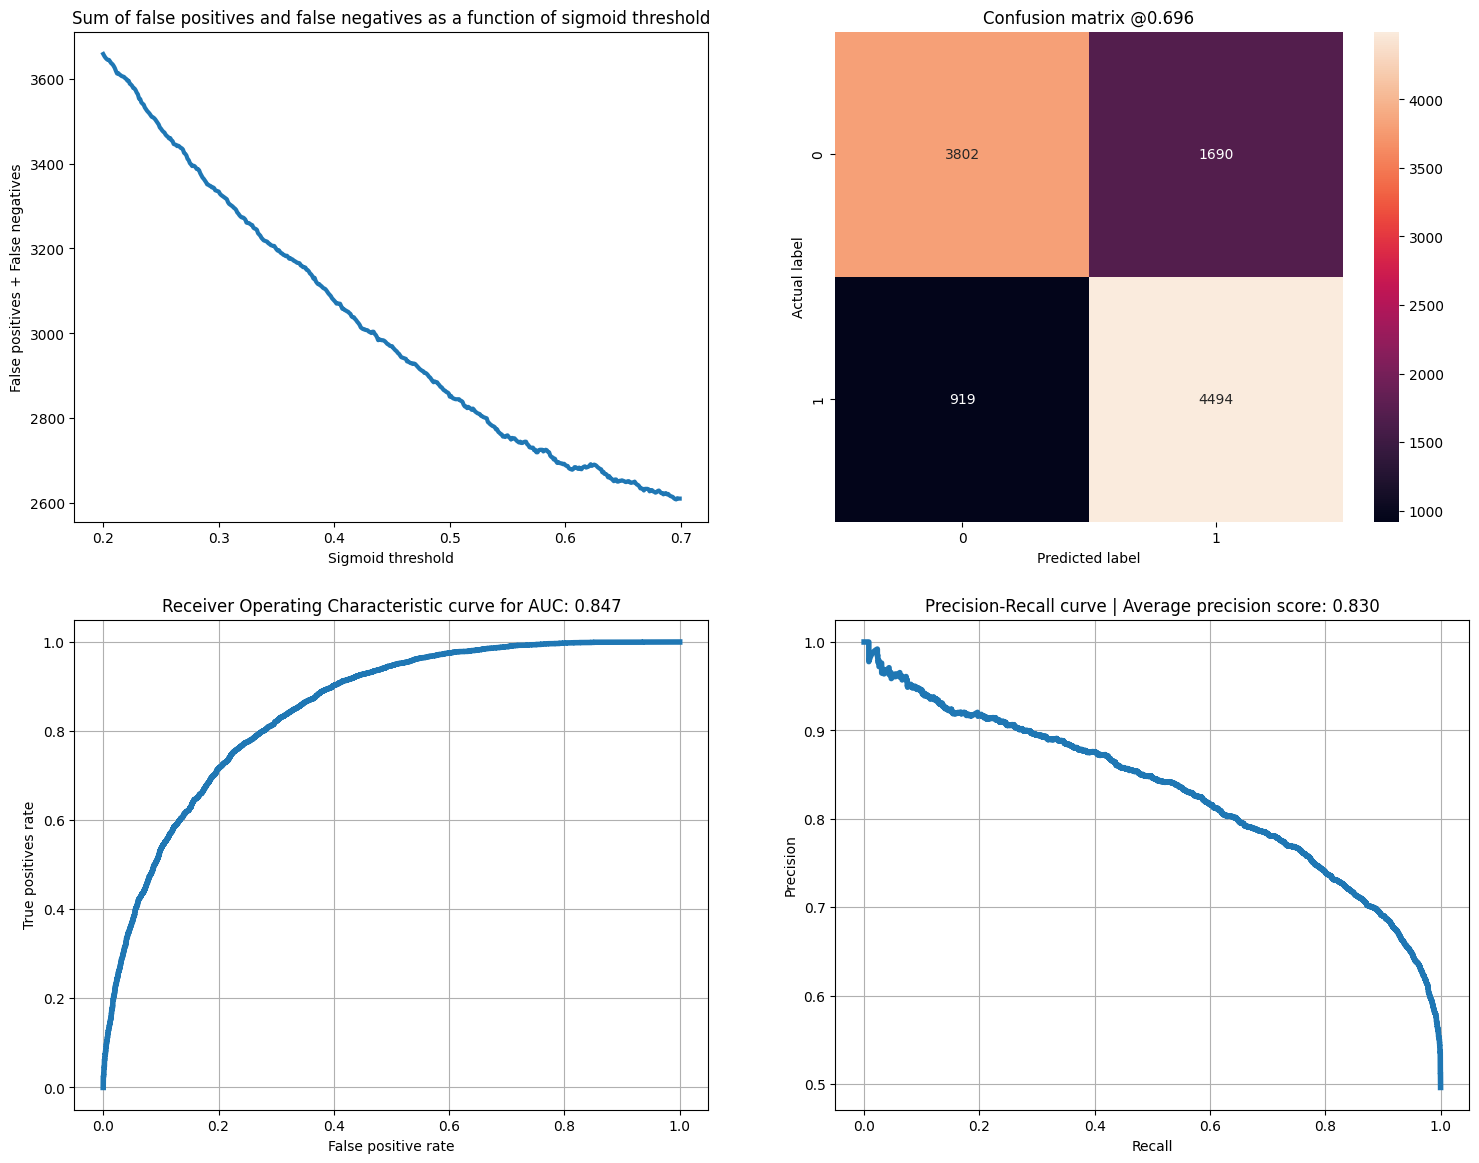

In [11]:
min_threshold = calculate_model_performance_metrics('model_inceptionv3', test_generator, show_plots=True)